In [1]:
import numpy as np
import pandas as pd
import random
from sklearn.linear_model import LogisticRegression
import sys

sys.path.insert(0, "../../../Modules")

pd.set_option('display.max_columns', None)
random.seed(0)
np.random.seed(0)

from utils import *

In [2]:
import warnings
warnings.filterwarnings("ignore")

In [3]:
NUTS0 = 'IT'
NUTS2 = 'Veneto'

In [4]:
f = open(f"../../data/{NUTS2}/{NUTS0}_{NUTS2}_WNV_2008-2019_Cases_Dates.txt", "r")
print(f.read())

months: 6, 7, 8, 9, 10, 11, 
years: 2008, 2009, 2010, 2011, 2012, 2013, 2014, 2015, 2016, 2017, 2018, 2019, 


In [5]:
r_u = 0.05
near_u = 0.35
smote = 1
scaler = 'minmax'
#years_to_remove = [year for year in range(2012, 2018)]
years_to_remove = []
path = f'../../data/{NUTS2}/{NUTS0}_{NUTS2}_WNV_Dataset_2008_2019.csv'

In [6]:
dataset = read_data(path, exclude_years = years_to_remove)
dataset.head()

,x,y,dt_placement,nuts2,lau1,day,month,week,year,day_sin,day_cos,month_sin,month_cos,week_sin,week_cos,population,eq_distance,ndvi,ndmi,ndwi,ndbi,ndvi_mean,ndmi_mean,ndwi_mean,ndbi_mean,ndvi_std,ndmi_std,ndwi_std,ndbi_std,lst,lst_day,lst_night,lst_jan_day_mean,lst_jan_night_mean,lst_feb_day_mean,lst_feb_night_mean,lst_mar_day_mean,lst_mar_night_mean,lst_apr_day_mean,lst_apr_night_mean,acc_rainfall_1week,acc_rainfall_2week,acc_rainfall_jan,distance_to_coast,distance_to_river,slope_mean_1km,aspect_mean_200m,elevation_mean_1km,hillshade_mean_1km,fs_area_1km,flow_accu_200m,lc_prop1,lc_prop1_assessment,lc_prop2,lc_prop2_assessment,lc_prop3,lc_prop3_assessment,lc_type1,lc_type2,lc_type3,lc_type4,lc_type5,lw,qc,mosq_pred,mosq_previous,case
0,11.79539,45.35783,2008-01-01,veneto,abano terme,1,1,1,2008,0.201299,0.97953,0.5,0.866025,0.118273,0.992981,"19,349",46.86645,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,8982.126981,2074.539971,3,170.409233,10.722186,179.966181,0.0,1.063084,31.0,99.0,36.0,99.0,30.0,99.0,12,12.0,1.0,6.0,7.0,2,0,1,0,0
1,12.04940,45.07048,2008-01-01,veneto,adria,1,1,1,2008,0.201299,0.97953,0.5,0.866025,0.118273,0.992981,"20,233",46.65336,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,5895.304596,2671.062303,1,142.510779,-0.844161,180.122652,0.0,1.399263,31.0,99.0,36.0,99.0,30.0,99.0,12,12.0,1.0,6.0,7.0,2,0,1,0,0
2,10.77673,45.55680,2008-01-01,veneto,affi,1,1,1,2008,0.201299,0.97953,0.5,0.866025,0.118273,0.992981,"2,297",46.81410,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,5306.025387,738.794180,6,207.641691,201.821006,178.733735,0.0,1.815834,22.0,90.0,20.0,90.0,20.0,90.0,9,9.0,4.0,1.0,1.0,2,0,7,0,0
3,11.96539,45.17531,2008-01-01,veneto,agna,1,1,1,2008,0.201299,0.97953,0.5,0.866025,0.118273,0.992981,"3,400",46.73306,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,16631.850238,1165.197945,3,121.193871,0.122498,180.188821,0.0,3.769479,31.0,99.0,36.0,99.0,30.0,99.0,12,12.0,1.0,6.0,7.0,2,0,4,0,0
4,12.05912,46.31399,2008-01-01,veneto,agordo,1,1,1,2008,0.201299,0.97953,0.5,0.866025,0.118273,0.992981,"4,249",47.85821,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,15023.566702,684.464446,18,124.001040,1470.386475,152.701532,0.0,2.289867,15.0,92.0,10.0,91.0,10.0,91.0,5,5.0,7.0,1.0,1.0,2,0,14,0,0


In [7]:
dataset = dataset.query('month >= 6 & month <= 11')
dataset.reset_index(inplace=True, drop=True)

In [8]:
dataset

,x,y,dt_placement,nuts2,lau1,day,month,week,year,day_sin,day_cos,month_sin,month_cos,week_sin,week_cos,population,eq_distance,ndvi,ndmi,ndwi,ndbi,ndvi_mean,ndmi_mean,ndwi_mean,ndbi_mean,ndvi_std,ndmi_std,ndwi_std,ndbi_std,lst,lst_day,lst_night,lst_jan_day_mean,lst_jan_night_mean,lst_feb_day_mean,lst_feb_night_mean,lst_mar_day_mean,lst_mar_night_mean,lst_apr_day_mean,lst_apr_night_mean,acc_rainfall_1week,acc_rainfall_2week,acc_rainfall_jan,distance_to_coast,distance_to_river,slope_mean_1km,aspect_mean_200m,elevation_mean_1km,hillshade_mean_1km,fs_area_1km,flow_accu_200m,lc_prop1,lc_prop1_assessment,lc_prop2,lc_prop2_assessment,lc_prop3,lc_prop3_assessment,lc_type1,lc_type2,lc_type3,lc_type4,lc_type5,lw,qc,mosq_pred,mosq_previous,case
0,11.79539,45.35783,2008-06-01,veneto,abano terme,1,6,22,2008,0.201299,0.979530,1.224647e-16,-1.000000,0.508531,-0.861044,"19,349",46.86645,0.328023,0.080399,-0.263422,-0.080399,0.363412,0.099211,-0.262222,-0.099211,0.055560,0.050767,0.021376,0.050767,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,8982.126981,2074.539971,3,170.409233,10.722186,179.966181,0.000000,1.063084,31.0,99.0,36.0,99.0,30.0,99.0,12,12.0,1.0,6.0,7.0,2,0,1,2,0
1,12.04940,45.07048,2008-06-01,veneto,adria,1,6,22,2008,0.201299,0.979530,1.224647e-16,-1.000000,0.508531,-0.861044,"20,233",46.65336,0.294697,0.065611,-0.254850,-0.065611,0.331777,0.095893,-0.252759,-0.095893,0.111285,0.121105,0.024888,0.121105,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,5895.304596,2671.062303,1,142.510779,-0.844161,180.122652,0.000000,1.399263,31.0,99.0,36.0,99.0,30.0,99.0,12,12.0,1.0,6.0,7.0,2,0,1,2,0
2,10.77673,45.55680,2008-06-01,veneto,affi,1,6,22,2008,0.201299,0.979530,1.224647e-16,-1.000000,0.508531,-0.861044,"2,297",46.81410,0.453163,0.214368,-0.218987,-0.214368,0.498889,0.203807,-0.264907,-0.203807,0.053675,0.050346,0.024386,0.050346,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,5306.025387,738.794180,6,207.641691,201.821006,178.733735,0.000000,1.815834,22.0,90.0,20.0,90.0,20.0,90.0,9,9.0,4.0,1.0,1.0,2,0,7,14,0
3,11.96539,45.17531,2008-06-01,veneto,agna,1,6,22,2008,0.201299,0.979530,1.224647e-16,-1.000000,0.508531,-0.861044,"3,400",46.73306,0.330621,0.065681,-0.279323,-0.065681,0.332201,0.068339,-0.278148,-0.068339,0.065406,0.061280,0.013125,0.061280,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,16631.850238,1165.197945,3,121.193871,0.122498,180.188821,0.000000,3.769479,31.0,99.0,36.0,99.0,30.0,99.0,12,12.0,1.0,6.0,7.0,2,0,4,8,0
4,12.05912,46.31399,2008-06-01,veneto,agordo,1,6,22,2008,0.201299,0.979530,1.224647e-16,-1.000000,0.508531,-0.861044,"4,249",47.85821,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,15023.566702,684.464446,18,124.001040,1470.386475,152.701532,0.000000,2.289867,15.0,92.0,10.0,91.0,10.0,91.0,5,5.0,7.0,1.0,1.0,2,0,14,28,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
82242,12.17878,46.38835,2019-11-16,veneto,zoppe da cadore,16,11,46,2019,-0.101168,-0.994869,-5.000000e-01,0.866025,-0.737833,0.674983,265,47.96042,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.000000,0.000000,0.000000,25000.599626,346.378682,37,238.788886,1403.106042,162.646151,0.000000,2.557130,15.0,94.0,10.0,96.0,10.0,96.0,5,5.0,6.0,4.0,4.0,2,0,8,16,0
82243,11.49430,45.43798,2019-11-16,veneto,zovencedo,16,11,46,2019,-0.101168,-0.994869,-5.000000e-01,0.866025,-0.737833,0.674983,796,46.86928,0.571322,0.155106,-0.465696,-0.155106,0.548208,0.162205,-0.425753,-0.162205,0.051183,0.051136,0.085044,0.051136,8.62,11.25,5.99,4.295000,-0.508182,11.538000,3.365556,18.535455,6.696667,19.732000,10.316667,227.983651,343.831703,1972.511516,5077.714670,1967.854592,35,131.888403,267.495086,193.006806,0.000000,1.

In [9]:
dataset['lau1'].unique().shape

(571,)

In [10]:
dsc = dataframe_describe(dataset)
dsc.head(15)

,year,non-case,case,total,percentage
0,2008,6851,1,6852,8.33%
1,2009,6846,6,6852,8.33%
2,2010,6845,7,6852,8.33%
3,2011,6843,9,6852,8.33%
4,2012,6823,32,6855,8.33%
5,2013,6826,27,6853,8.33%
6,2014,6850,2,6852,8.33%
7,2015,6851,1,6852,8.33%
8,2016,6843,9,6852,8.33%
9,2017,6837,16,6853,8.33%


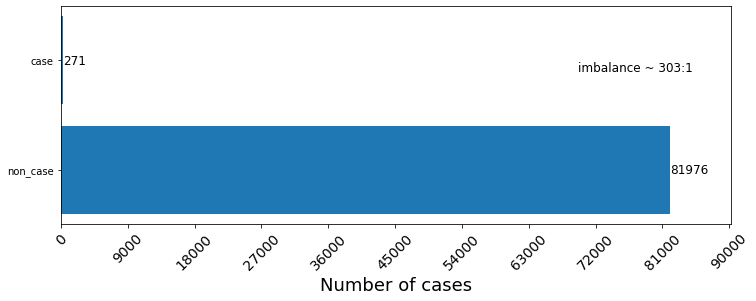

In [11]:
plot_imbalance(dataset)

In [12]:
path2 = f'../../data/{NUTS2}/{NUTS0}_{NUTS2}_WNV_Dataset_2023-June-1st.csv'
data_test = read_data(path2, exclude_years = years_to_remove)
data_test.head()

,x,y,dt_placement,nuts2,lau1,day,month,week,year,day_sin,day_cos,month_sin,month_cos,week_sin,week_cos,population,eq_distance,ndvi,ndmi,ndwi,ndbi,ndvi_mean,ndmi_mean,ndwi_mean,ndbi_mean,ndvi_std,ndmi_std,ndwi_std,ndbi_std,lst,lst_day,lst_night,lst_jan_day_mean,lst_jan_night_mean,lst_feb_day_mean,lst_feb_night_mean,lst_mar_day_mean,lst_mar_night_mean,lst_apr_day_mean,lst_apr_night_mean,acc_rainfall_1week,acc_rainfall_2week,acc_rainfall_jan,distance_to_coast,distance_to_river,slope_mean_1km,aspect_mean_200m,elevation_mean_1km,hillshade_mean_1km,fs_area_1km,flow_accu_200m,lc_prop1,lc_prop1_assessment,lc_prop2,lc_prop2_assessment,lc_prop3,lc_prop3_assessment,lc_type1,lc_type2,lc_type3,lc_type4,lc_type5,lw,qc,mosq_pred,mosq_previous,case
0,11.79539,45.35783,2023-06-01,veneto,abano terme,1,6,22,2023,0.201299,0.97953,1.224647e-16,-1.0,0.508531,-0.861044,"19,349",46.86645,0.352708,0.076309,-0.323681,-0.076309,0.432954,0.129068,-0.379556,-0.129068,0.091163,0.066888,0.064304,0.066888,25.150000,32.11,18.190000,7.577500,0.803333,8.080000,-0.791538,18.345385,6.490000,21.500769,6.950000,13.810195,25.856935,282.321519,8982.126981,2074.539971,3,170.409233,10.722186,179.966181,0.0,1.063084,31,98.0,36,98.0,30,98.0,12,12,1,6,7,2,0,112,0,0
1,12.04940,45.07048,2023-06-01,veneto,adria,1,6,22,2023,0.201299,0.97953,1.224647e-16,-1.0,0.508531,-0.861044,"20,233",46.65336,0.453333,0.172967,-0.412264,-0.172967,0.401527,0.130960,-0.375370,-0.130960,0.107333,0.117531,0.074074,0.117531,23.346667,30.61,16.083333,6.080278,1.536222,8.109212,-1.341825,16.869545,4.825897,21.349744,5.723333,13.696820,24.735838,499.108336,5895.304596,2671.062303,1,142.510779,-0.844161,180.122652,0.0,1.399263,31,99.0,36,99.0,30,99.0,12,12,1,6,7,2,0,453,0,0
2,10.77673,45.55680,2023-06-01,veneto,affi,1,6,22,2023,0.201299,0.97953,1.224647e-16,-1.0,0.508531,-0.861044,"2,297",46.81410,0.329751,0.043112,-0.324574,-0.043112,0.465339,0.155617,-0.401987,-0.155617,0.055714,0.026191,0.047542,0.026191,21.670000,27.35,15.990000,6.294444,0.807143,8.631538,0.720667,17.180000,4.251429,18.359412,6.878889,7.265024,35.054694,139.243551,5306.025387,738.794180,6,207.641691,201.821006,178.733735,0.0,1.815834,31,84.0,30,84.0,30,84.0,10,10,1,6,6,2,0,61,0,0
3,11.96539,45.17531,2023-06-01,veneto,agna,1,6,22,2023,0.201299,0.97953,1.224647e-16,-1.0,0.508531,-0.861044,"3,400",46.73306,0.304736,0.005350,-0.306680,-0.005350,0.411564,0.135998,-0.374753,-0.135998,0.102565,0.107583,0.067687,0.107583,23.390000,29.81,16.970000,4.340000,0.585000,7.752222,-2.034615,15.996667,4.427778,21.254615,5.119231,28.850230,44.931100,474.424890,16631.850238,1165.197945,3,121.193871,0.122498,180.188821,0.0,3.769479,31,99.0,36,99.0,30,99.0,12,12,1,6,7,2,0,170,0,0
4,12.05912,46.31399,2023-06-01,veneto,agordo,1,6,22,2023,0.201299,0.97953,1.224647e-16,-1.0,0.508531,-0.861044,"4,249",47.85821,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.000000,0.000000,0.000000,15023.566702,684.464446,18,124.001040,1470.386475,152.701532,0.0,2.289867,15,91.0,10,97.0,10,97.0,5,5,7,1,1,2,0,16,0,0


In [13]:
coefficients = []
results_train = pd.DataFrame()
results_test = pd.DataFrame()
feature_names = dataset.select_dtypes(exclude=['object']).drop(columns = ['case']).columns

In [14]:
data_train = dataset
data_test = data_test
    
data_train.reset_index(inplace = True, drop = True)
data_test.reset_index(inplace = True, drop = True)
    
X_train = data_train.select_dtypes(exclude=['object']).drop(columns = ['case'])
y_train = data_train['case']
X_test = data_test.select_dtypes(exclude=['object']).drop(columns = ['case'])
y_test = data_test['case']
    
X_train, X_test, y_train, y_test, X_train_df = transform_data(X_train, X_test, y_train, y_test, r_u, near_u, smote, scaler_key=scaler)
    
w0,w1 = calculate_weights(y_train)

model = LogisticRegression(max_iter = 1000, class_weight = {0.0: w0, 1.0:w1}, n_jobs = -1, random_state = 0)
    
train, test, coef = train_and_predict(model, X_train_df, data_test, X_train, y_train, X_test, y_test)
    
results_train = results_train.append(train, ignore_index = True)
results_test = results_test.append(test, ignore_index = True)
coefficients.append(coef)
    
print(f"Year: {test['year'].iloc[0]} || w0:{w0}, w1:{w1} || ##")

Year: 2023 || w0:1, w1:97 || ##


In [15]:
results_test.drop(columns='case').head(40)

,x,y,municipality,day,month,year,probability
0,12.24756,45.27153,chioggia,1,6,2023,0.476348
1,12.32478,45.43497,venezia,1,6,2023,0.389475
2,12.18085,45.26512,codevigo,1,6,2023,0.296706
3,12.49633,45.47024,cavallino treporti,1,6,2023,0.126566
4,12.30160,45.08601,rosolina,1,6,2023,0.117897
5,12.20556,45.34104,campagna lupia,1,6,2023,0.085289
6,11.73897,44.96915,polesella,1,6,2023,0.027920
7,12.42147,44.91853,porto tolle,1,6,2023,0.027894
8,12.64230,45.55959,jesolo,1,6,2023,0.026647
9,11.44609,44.95767,ficarolo,1,6,2023,0.016224
